# Note onset detection

Simulator anbd investigator for note onset detection on chunks.

**Conclusions:**

- provide `slide_length` and `hop_length` everywhere!
- Detecting onset is unsuited point to subsequently determine played note via chromagram, as the onset is before the attack, where the chromagram energy is still low
  - instead, we use the envelope peak location for note determionation: `peak_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, normalize=True, backtrack=False, hop_length=hop_length)`
  - we still compute the onset, as it determines the time the note starts: `onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, normalize=True, backtrack=True, hop_length=hop_length)`
- An alternative to detecting the note onsets on the audio wave form is to detect the notes (aka peaks) on each chromagram lane / pitch separately
  - Works quite nice if chromagram is thresholded beforehand
  - Removes need to determine the played note at onset
  
**Preliminary conclusion**:
- use computation on chromagram
- set new = 3 * 1024 (can be less)
- set carryover = 8 * 1024 (can be less)
- set hoip length = 512 (can be 1024)
- set chroma threshold = 0.3
- allow peaks that appear either in new frames or up top two frames before that

In [28]:
import numpy as np
import librosa
import audioflux as af
import matplotlib.pyplot as plt
from audioflux.display import fill_spec
from audioflux.type import (
    SpectralFilterBankScaleType,
    SpectralFilterBankStyleType,
    SpectralFilterBankNormalType,
    ChromaDataNormalType,
    SpectralDataType,
)
from audioflux.utils import note_to_hz
import IPython.display as ipd
import plotly.express as px
import pandas as pd

### Load audio

In [29]:
# 880Hz tone
# sample_path = af.utils.sample_path('880')
# y, sr = af.read(sample_path)

In [30]:
# midi file (increasing notes over one octave)
y, sr = af.read("audio/midi_chunk/midi_chunk_oneoctave_c2plus.wav")

### Audio details

In [31]:
print(f"{y.shape} samples\n", f"{sr} sample rate\n", f"{y.shape[0] / sr} seconds\n", f"{y.max()} / {y.min()} min/max")

(164992,) samples
 44100 sample rate
 3.7413151927437642 seconds
 0.107757568359375 / -0.092315673828125 min/max


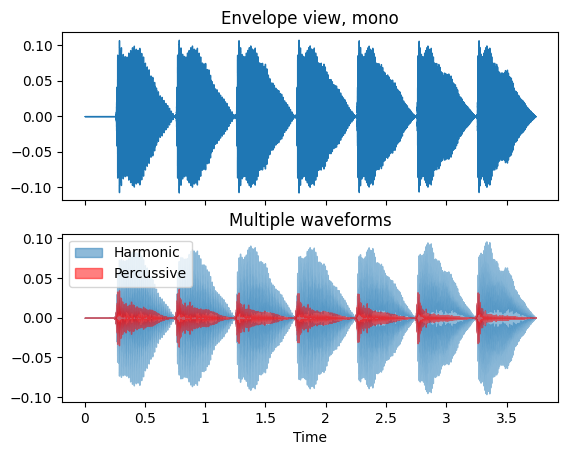

In [32]:
y_harm, y_perc = librosa.effects.hpss(y)

fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.waveshow(y, sr=sr, axis="m", ax=ax[0])
ax[0].set(title="Envelope view, mono")
ax[0].label_outer()
librosa.display.waveshow(y_harm, sr=sr, alpha=0.5, ax=ax[1], label="Harmonic")
librosa.display.waveshow(y_perc, sr=sr, color="r", alpha=0.5, ax=ax[1], label="Percussive")
ax[1].set(title="Multiple waveforms")
ax[1].legend()

In [33]:
ipd.Audio(y, rate=sr)

### Computation using whole audio data

In [65]:
slide_length = hop_length = 1024

#### Compute CQT and chromagram

In [66]:
cqt_obj = af.CQT(
    num=84,
    samplate=sr,
    low_fre=note_to_hz("C1"),
    bin_per_octave=12,
    slide_length=slide_length,
    normal_type=SpectralFilterBankNormalType.AREA,
)
# SpectralFilterBankNormalType.NONE | AREA | BAND_WIDTH
y_cqt = cqt_obj.cqt(y)
print(y_cqt.shape, y_cqt.min(), y_cqt.max())

(84, 162) (-2.205166+0.22584125j) (2.2757485+0.4515467j)


In [67]:
y_chroma = cqt_obj.chroma(y_cqt, chroma_num=12, data_type=SpectralDataType.POWER, norm_type=ChromaDataNormalType.P1)
# ChromaDataNormalType.MAX | P1 | P2
print(y_chroma.shape, y_chroma.min(), y_chroma.max())

(12, 162) 0.00010478556 0.792824


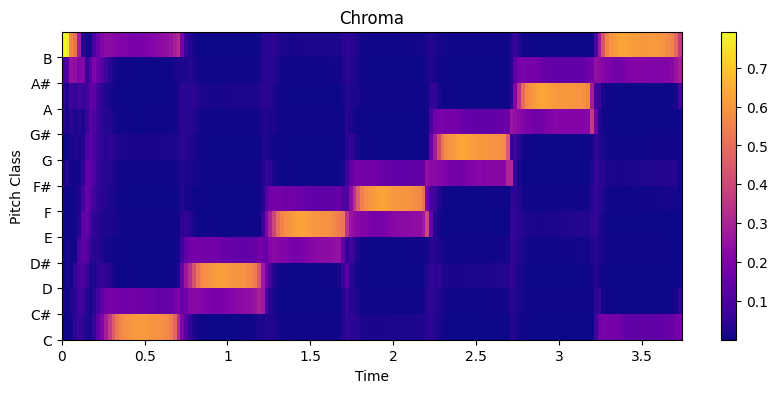

In [68]:
fig, ax = plt.subplots(figsize=(10, 4))
img = fill_spec(y_chroma, axes=ax, x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax.set_ylabel("Pitch Class")
ax.set_yticks(range(12))
ax.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
fig.colorbar(img, ax=ax)

#### Detect onset strength

In [69]:
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
print(onset_env.shape, onset_env.min(), onset_env.max())

(162,) 0.0 25.293901


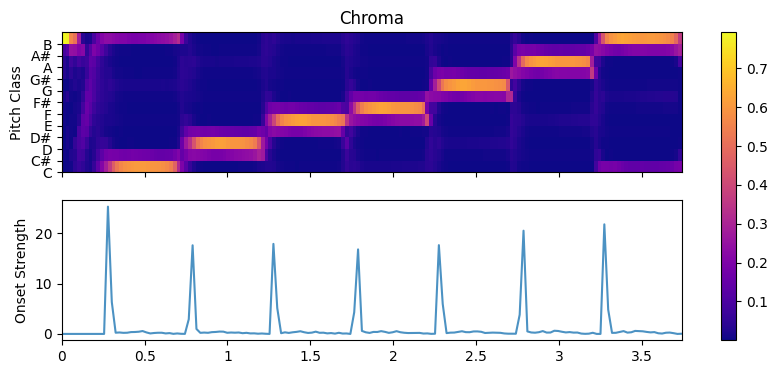

In [70]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 4))

img = fill_spec(y_chroma, axes=ax[0], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()
fig.colorbar(img, ax=ax)

times = librosa.times_like(onset_env, sr=sr, hop_length=hop_length)
ax[1].plot(times, onset_env, alpha=0.8, label="Onset Strength")
ax[1].set_ylabel("Onset Strength")
ax[1].label_outer()

#### Detect note onsets

In [71]:
onset_frames = librosa.onset.onset_detect(
    onset_envelope=onset_env, sr=sr, normalize=True, backtrack=True, hop_length=hop_length
)
peak_frames = librosa.onset.onset_detect(
    onset_envelope=onset_env, sr=sr, normalize=True, backtrack=False, hop_length=hop_length
)

print(onset_frames)
print(peak_frames)

[ 11  32  54  75  96 117 140]
[ 12  34  55  76  98 120 141]


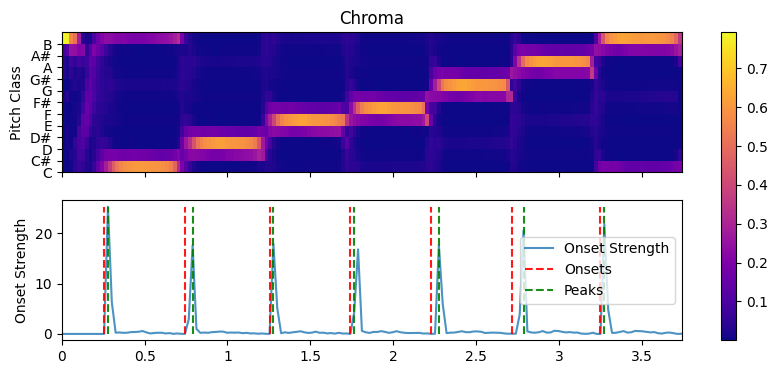

In [72]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 4))

img = fill_spec(y_chroma, axes=ax[0], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()
fig.colorbar(img, ax=ax)

times = librosa.times_like(onset_env, sr=sr, hop_length=hop_length)
ax[1].plot(times, onset_env, alpha=0.8, label="Onset Strength")
ax[1].vlines(times[onset_frames], 0, onset_env.max(), color="r", alpha=0.9, linestyle="--", label="Onsets")
ax[1].vlines(times[peak_frames], 0, onset_env.max(), color="g", alpha=0.9, linestyle="--", label="Peaks")
ax[1].set_ylabel("Onset Strength")
ax[1].label_outer()
ax[1].legend()

- note onset is moved to an earlier point - which makes sense, as the onset is before the peak (before the attack)
- but that means that detecting the note type via chromagram stength at that point possibly won't work
  - rather use detected onset for timing, but real peak for note type extraction

#### Identify notes starting at onset

In [73]:
threshold = 0.4

# Extract notes at onset frames
notes_with_onsets = []
for o_frame, p_frame in zip(onset_frames, peak_frames):
    chroma_frame = y_chroma[:, p_frame]
    frame_time = librosa.frames_to_time(o_frame, sr=sr, hop_length=hop_length)

    # Find all notes above the threshold
    active_note_found = False
    for i, magnitude in enumerate(chroma_frame):
        if magnitude > threshold:
            notes_with_onsets.append((i % 12, frame_time, np.nan, magnitude))
            active_note_found = True

    # If no notes are above threshold, take the highest one
    if not active_note_found:
        max_index = int(np.argmax(chroma_frame))
        notes_with_onsets.append((max_index % 12, frame_time, np.nan, chroma_frame[max_index]))

In [74]:
notes_with_onsets

[(0, np.float64(0.25541950113378686), nan, np.float32(0.3636834)),
 (2, np.float64(0.7430385487528345), nan, np.float32(0.42946783)),
 (4, np.float64(1.253877551020408), nan, np.float32(0.3919796)),
 (5, np.float64(1.7414965986394557), nan, np.float32(0.33779484)),
 (7, np.float64(2.2291156462585033), nan, np.float32(0.4040111)),
 (9, np.float64(2.716734693877551), nan, np.float32(0.4887533)),
 (11, np.float64(3.250793650793651), nan, np.float32(0.43462142))]

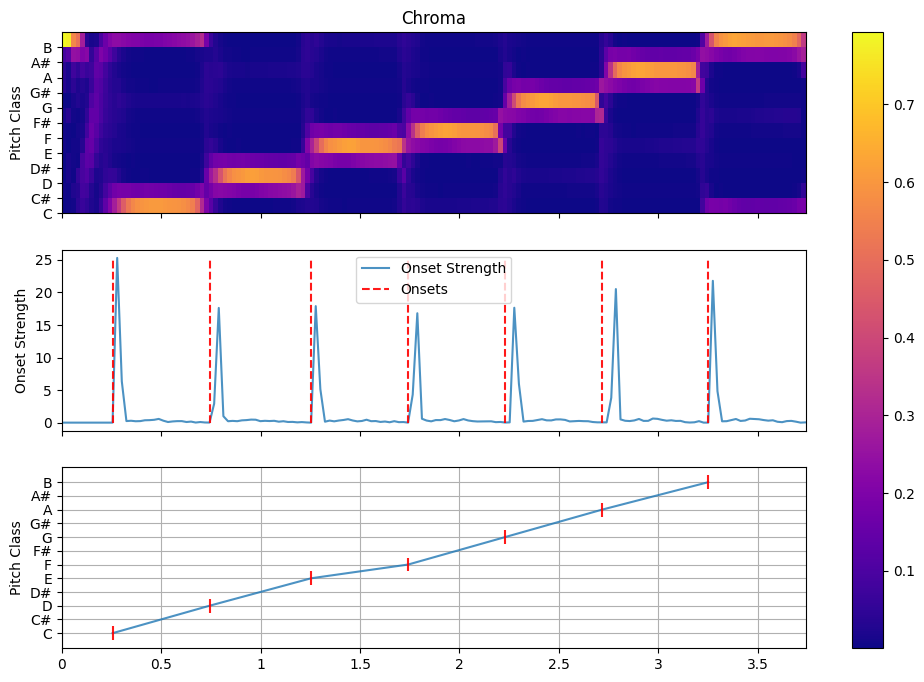

In [75]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(12, 8))

img = fill_spec(y_chroma, axes=ax[0], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()
fig.colorbar(img, ax=ax)

times = librosa.times_like(onset_env, sr=sr, hop_length=hop_length)
ax[1].plot(times, onset_env, alpha=0.8, label="Onset Strength")
ax[1].vlines(times[onset_frames], 0, onset_env.max(), color="r", alpha=0.9, linestyle="--", label="Onsets")
ax[1].set_ylabel("Onset Strength")
ax[1].label_outer()
ax[1].legend()

notes_ids = np.asarray([id for id, _, _, _ in notes_with_onsets])
notes_onsets = [float(o) for _, o, _, _ in notes_with_onsets]
ax[2].plot(notes_onsets, notes_ids, alpha=0.8, label="Detected Notes")
ax[2].vlines(notes_onsets, notes_ids - 0.5, notes_ids + 0.5, color="r", alpha=0.9, linestyle="-", label="Onsets")
ax[2].set_yticks(range(12))
ax[2].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[2].set_ylabel("Pitch Class")
ax[2].label_outer()
ax[2].grid()

Nice, way better!

### Onset detection per chroma pitch class

Here we try if we can detect the notes directly on the chromagram, instead of on the amplitude. This might help us to become more sensitive to sub notes starting aroudn the same time.

But it might also become too sensitive.

In [45]:
threshold = 0.4

y_chroma_thresholded = y_chroma.copy()
y_chroma_thresholded[y_chroma_thresholded < threshold] = 0

detected = {}
for note_id in range(y_chroma.shape[0]):
    _onset_env = librosa.onset.onset_strength(
        S=librosa.amplitude_to_db(y_chroma_thresholded[note_id]), hop_length=hop_length
    )
    _onset_frames = librosa.onset.onset_detect(
        onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=True, hop_length=hop_length
    )
    detected[note_id] = (_onset_env, _onset_frames)

/tmp/ipykernel_41526/428435987.py:21: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(times, note_id + _onset_env / _onset_env.max(), alpha=0.8, label="Onset Strength")


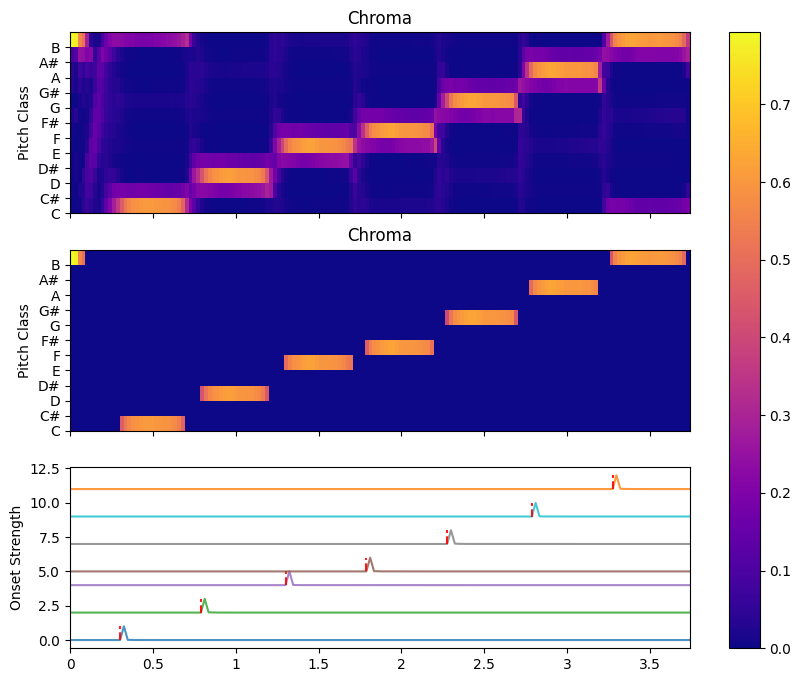

In [46]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 8))

img = fill_spec(y_chroma, axes=ax[0], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()

img = fill_spec(
    y_chroma_thresholded, axes=ax[1], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma"
)
ax[1].set_yticks(range(12))
ax[1].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[1].set_ylabel("Pitch Class")
ax[1].label_outer()

fig.colorbar(img, ax=ax)

for note_id, (_onset_env, _onset_frames) in detected.items():
    times = librosa.times_like(_onset_env, sr=sr, hop_length=hop_length)
    ax[2].plot(times, note_id + _onset_env / _onset_env.max(), alpha=0.8, label="Onset Strength")
    ax[2].vlines(times[_onset_frames], note_id, note_id + 1, color="r", alpha=0.9, linestyle="--", label="Onsets")
ax[2].set_ylabel("Onset Strength")
ax[2].label_outer()
# ax[1].legend()

- Doesn't look half bad.
- Wouldn't need peak detection, as chroma lane already known.
- But might depend a little bit too much on the selection of the threshold.

### Investigate audio chunk wise computation
Example computation for single chunks.

In [63]:
n_new_samples = 1024 * 1 - 1
n_carryover_samples = 1024 * 8

threshold = 0.25

notes_onset_env = [[] for i in range(12)]
notes_onset_frames = [[] for i in range(12)]
notes_peak_frames = [[] for i in range(12)]

chunk_offset_no = 6
i = n_carryover_samples + chunk_offset_no * n_new_samples

# get chunk
chunk = y[i - n_carryover_samples : i + n_new_samples]

# compute chromagram
chunk_cqt = cqt_obj.cqt(chunk)
chunk_chroma = cqt_obj.chroma(
    chunk_cqt, chroma_num=12, data_type=SpectralDataType.POWER, norm_type=ChromaDataNormalType.P1
)

# detect notes
chunk_chroma_thresholded = chunk_chroma.copy()
chunk_chroma_thresholded[chunk_chroma_thresholded < threshold] = 0

detected = {}
for note_id in range(y_chroma.shape[0]):
    _onset_env = librosa.onset.onset_strength(
        S=librosa.amplitude_to_db(chunk_chroma_thresholded[note_id]), hop_length=hop_length
    )
    if _onset_env.max() > 0:
        print(note_id, _onset_env.max(), _onset_env[n_carryover_samples // slide_length :].max())
    _onset_frames = librosa.onset.onset_detect(
        onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=True, hop_length=hop_length
    )
    _peak_frames = librosa.onset.onset_detect(
        onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=False, hop_length=hop_length
    )
    notes_onset_env[note_id] = _onset_env
    notes_onset_frames[note_id] = _onset_frames
    notes_peak_frames[note_id] = _peak_frames

0 78.14621 0.22114754


/tmp/ipykernel_41526/1597474912.py:24: RuntimeWarning:

invalid value encountered in divide



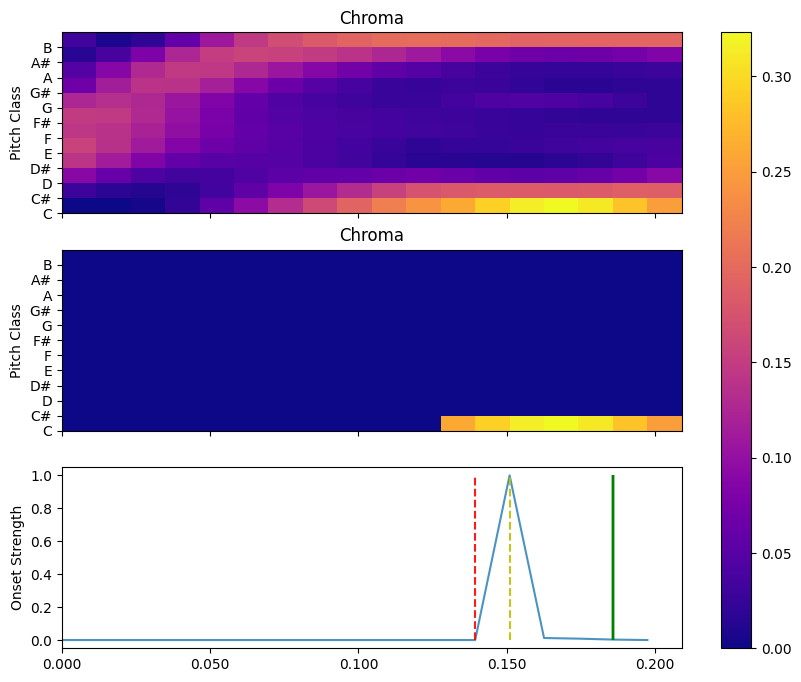

In [64]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 8))

img = fill_spec(chunk_chroma, axes=ax[0], x_coords=cqt_obj.x_coords(chunk.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()

img = fill_spec(
    chunk_chroma_thresholded, axes=ax[1], x_coords=cqt_obj.x_coords(chunk.shape[-1]), x_axis="time", title="Chroma"
)
ax[1].set_yticks(range(12))
ax[1].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[1].set_ylabel("Pitch Class")
ax[1].label_outer()

fig.colorbar(img, ax=ax)

for note_id in range(12):
    _onset_env = notes_onset_env[note_id]
    _onset_frames = notes_onset_frames[note_id]
    _peak_frames = notes_peak_frames[note_id]
    times = librosa.times_like(_onset_env, sr=sr, hop_length=hop_length)
    ax[2].plot(times, note_id + _onset_env / _onset_env.max(), alpha=0.8, label="Onset Strength")
    ax[2].vlines(times[_onset_frames], note_id, note_id + 1, color="r", alpha=0.9, linestyle="--", label="Onset")
    ax[2].vlines(times[_peak_frames], note_id, note_id + 1, color="y", alpha=0.9, linestyle="--", label="Peak")
    ax[2].vlines(
        [librosa.samples_to_time(n_carryover_samples, sr=sr)],
        0,
        1,
        color="g",
        alpha=0.9,
        linestyle="-",
        label="New threshold",
    )
ax[2].set_ylabel("Onset Strength")
ax[2].label_outer()
# ax[2].legend()

Notes:
- a chunks chroma, if there is constant activity, has normal distributed intensity (shallow start, shallow end)
- that means peaks are detected
- if the sound is new, rather to the right
- if the sound is older, rather further on the left
- this might help to distinguish
- since we work on chroma, we don't need necesarily to look at peak - but more clerar, otherwise threshold would have to be further to the left

- using new frames as threshold does NOT work - chromagram to smooth towards the right border

- using 2*1024 new samples delays the onset detection - and makes it harder to set the threshold, as peak will be further left
- maybe, after a peak is detected, disallow a new peak at the same chroma for 1-2 ticks

Idea to try:

- allow peak up to 1-2 frames before the threshold frame designating the new samples
- disallow new peaks on the same chroma for 1-2 ticks after the detection of an onset



### Compute using audio chunks
This reflect the situation when reading from an audio stream.

In [49]:
slide_length = hop_length = 512

cqt_obj = af.CQT(
    num=84,
    samplate=sr,
    low_fre=note_to_hz("C1"),
    bin_per_octave=12,
    slide_length=slide_length,
    normal_type=SpectralFilterBankNormalType.AREA,
)

In [50]:
n_new_samples = 1024 * 3 - 1
n_carryover_samples = 1024 * 8

threshold = 0.3  # minimum required chroma energy
note_peak_margin_frames = 2  # we allow peaks that many frames before the new samples to be recognized as valid
peak_detection_suspension_ticks = 1  # not implemented so far

y_chroma_chunked = []
y_chroma_chunked_thresholded = []
notes_onset_env = [[] for i in range(12)]
notes_onset_frames = [[] for i in range(12)]

peak_detection_suspension_counter = [0 for i in range(12)]

for i in range(
    n_carryover_samples, y.shape[-1] - n_new_samples, n_new_samples
):  # NOTE: Running till end kills chroma computation
    chunk = y[i - n_carryover_samples : i + n_new_samples]

    # compute chromagram
    chunk_cqt = cqt_obj.cqt(chunk)
    chunk_chroma = cqt_obj.chroma(
        chunk_cqt, chroma_num=12, data_type=SpectralDataType.POWER, norm_type=ChromaDataNormalType.P1
    )
    y_chroma_chunked.append(chunk_chroma[:, n_carryover_samples // slide_length :])

    # detect notes
    chunk_chroma_thresholded = chunk_chroma.copy()
    chunk_chroma_thresholded[chunk_chroma_thresholded < threshold] = 0
    y_chroma_chunked_thresholded.append(chunk_chroma_thresholded[:, n_carryover_samples // slide_length :])

    detected = {}
    for note_id in range(chunk_chroma.shape[0]):
        _onset_env = librosa.onset.onset_strength(
            S=librosa.amplitude_to_db(chunk_chroma_thresholded[note_id]), hop_length=hop_length
        )
        notes_onset_env[note_id].append(_onset_env[n_carryover_samples // slide_length :])

        _onset_frames = librosa.onset.onset_detect(
            onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=True, hop_length=hop_length
        )
        _peak_frames = librosa.onset.onset_detect(
            onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=False, hop_length=hop_length
        )
        # _peak_frames = librosa.onset.onset_detect(
        #    onset_envelope=_onset_env, sr=sr, normalize=True, backtrack=False, hop_length=hop_length
        # )
        # if len(_peak_frames) > 0:
        #    print(_peak_frames)
        #    _onset_frames = librosa.onset.onset_backtrack(_peak_frames, _onset_env)
        # else:
        #    _onset_frames = np.zeros(0)

        new_samples_threshold_frame = librosa.samples_to_frames(n_carryover_samples, hop_length=hop_length)
        peak_detection_threshold_frame = new_samples_threshold_frame - note_peak_margin_frames
        # if len(_peak_frames) > 0:
        #    print(_onset_env.shape)
        #    print(note_id, _peak_frames, peak_detection_threshold_frame)
        #    # print(librosa.samples_to_frames(i, hop_length=hop_length))
        _peaks_in_new_samples = _peak_frames >= peak_detection_threshold_frame
        # if _peaks_in_new_samples.any():
        #    print(note_id, _peak_frames, _peaks_in_new_samples)
        _onset_frames = _onset_frames[_peaks_in_new_samples]
        # current position (i) minus the carry over; minus the carry over that the analysis started delayed (one carry over); plust one?
        _onset_frames += librosa.samples_to_frames(i, hop_length=hop_length) - 2 * new_samples_threshold_frame + 1

        notes_onset_frames[note_id].append(_onset_frames)


# assemble
y_chroma_chunked = np.concat(y_chroma_chunked, axis=1)
y_chroma_chunked_thresholded = np.concat(y_chroma_chunked_thresholded, axis=1)
notes_onset_env = [np.concat(oes) for oes in notes_onset_env]
notes_onset_frames = [np.concat(ofs) for ofs in notes_onset_frames]

# pad end if required
_diff = librosa.samples_to_frames(y.shape[-1], hop_length=hop_length) + 1 - y_chroma_chunked.shape[1]
y_chroma_chunked = np.pad(y_chroma_chunked, ((0, 0), (0, _diff)), mode="edge")
y_chroma_chunked_thresholded = np.pad(y_chroma_chunked_thresholded, ((0, 0), (0, _diff)), mode="edge")
notes_onset_env = [np.pad(oe, (0, _diff), mode="constant") for oe in notes_onset_env]

In [51]:
print(y_chroma_chunked.shape, y_chroma_chunked.min(), y_chroma_chunked.max())
print(y_chroma_chunked_thresholded.shape, y_chroma_chunked_thresholded.min(), y_chroma_chunked_thresholded.max())
print(notes_onset_env[0].shape, notes_onset_env[0].min(), notes_onset_env[0].max())
# print(notes_onset_frames[0].shape, notes_onset_frames[0].min(), notes_onset_frames[0].max())

(12, 323) 0.00022043337 0.62626016
(12, 323) 0.0 0.62626016
(323,) 0.0 0.5979743


/tmp/ipykernel_41526/1379976042.py:23: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(times, note_id + _onset_env / _onset_env.max(), alpha=0.8, label="Onset Strength")


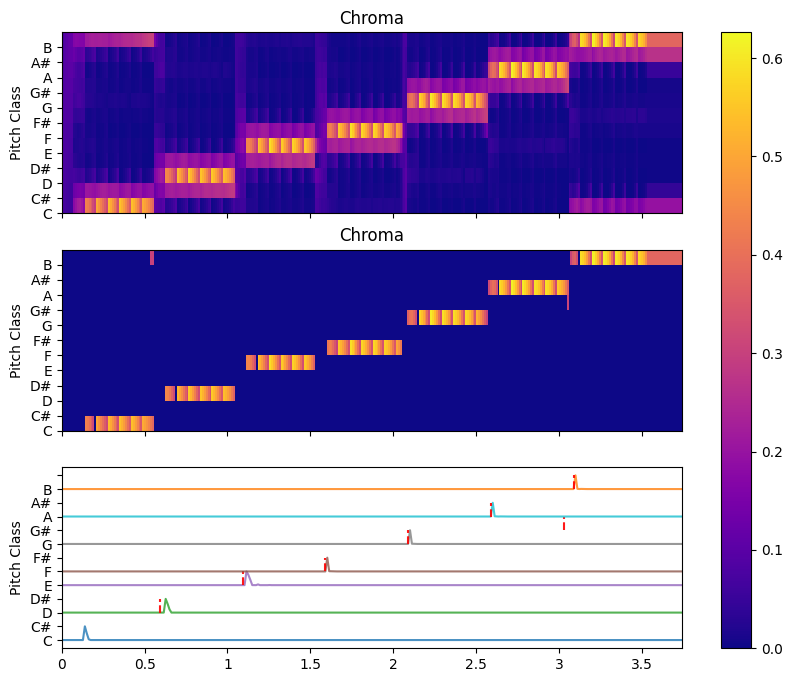

In [52]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 8))

img = fill_spec(y_chroma_chunked, axes=ax[0], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax[0].set_yticks(range(12))
ax[0].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[0].set_ylabel("Pitch Class")
ax[0].label_outer()

img = fill_spec(
    y_chroma_chunked_thresholded, axes=ax[1], x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma"
)
ax[1].set_yticks(range(12))
ax[1].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax[1].set_ylabel("Pitch Class")
ax[1].label_outer()

fig.colorbar(img, ax=ax)

for note_id in range(12):
    _onset_env = notes_onset_env[note_id]
    _onset_frames = notes_onset_frames[note_id]
    times = librosa.times_like(_onset_env, sr=sr, hop_length=hop_length)
    ax[2].plot(times, note_id + _onset_env / _onset_env.max(), alpha=0.8, label="Onset Strength")
    ax[2].vlines(times[_onset_frames], note_id, note_id + 1, color="r", alpha=0.9, linestyle="--", label="Onsets")
ax[2].set_yticks(range(13))
ax[2].set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B", ""])
ax[2].set_ylabel("Pitch Class")
ax[2].label_outer()
# ax[1].legend()

Observations so far:
- Peaks nicely detected (with new=2 and carryovber=8)
  - peaks must determine whether considered real onset (must be in new)
  - onset frame decides where on the timeline to place the onseet
- Onsets relatively frickle
  - on chunks, they are detected a few frames too late
  - we have to allow to look further back
  - accuracy depends on many settings and parameters
- Threshold the same as for general P1 normalization - chunking doesn't change this (~0.25-0.3)
  
- Unlcear yet is hop_length has any influence
  - Has... but unclear if 512 better or 1024... maybe rather the earlier?

- Unclear yet if better on chromagram or on waveform

Preliminary conclusion:
- use cpomputation on chromagram
- set new = 3 * 1024 (can be less)
- set carryover = 8 * 1024 (can be less)
- set hoip length = 512 (can be 1024)
- set chroma threshold = 0.3
- allow peaks that appear either in new frames or up top two frames before that

In [53]:
_onset_env.shape

(323,)

In [54]:
px.line(x=times, y=notes_onset_env[2])

In [55]:
times

array([0.        , 0.01160998, 0.02321995, 0.03482993, 0.04643991,
       0.05804989, 0.06965986, 0.08126984, 0.09287982, 0.1044898 ,
       0.11609977, 0.12770975, 0.13931973, 0.15092971, 0.16253968,
       0.17414966, 0.18575964, 0.19736961, 0.20897959, 0.22058957,
       0.23219955, 0.24380952, 0.2554195 , 0.26702948, 0.27863946,
       0.29024943, 0.30185941, 0.31346939, 0.32507937, 0.33668934,
       0.34829932, 0.3599093 , 0.37151927, 0.38312925, 0.39473923,
       0.40634921, 0.41795918, 0.42956916, 0.44117914, 0.45278912,
       0.46439909, 0.47600907, 0.48761905, 0.49922902, 0.510839  ,
       0.52244898, 0.53405896, 0.54566893, 0.55727891, 0.56888889,
       0.58049887, 0.59210884, 0.60371882, 0.6153288 , 0.62693878,
       0.63854875, 0.65015873, 0.66176871, 0.67337868, 0.68498866,
       0.69659864, 0.70820862, 0.71981859, 0.73142857, 0.74303855,
       0.75464853, 0.7662585 , 0.77786848, 0.78947846, 0.80108844,
       0.81269841, 0.82430839, 0.83591837, 0.84752834, 0.85913

### Appendix

In [56]:
y_chroma_normed.shape

NameError: name 'y_chroma_normed' is not defined

In [26]:
librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, normalize=True, backtrack=True, hop_length=1024)

array([ 22,  63, 106, 150, 194, 237, 280])

In [27]:
onset_env.shape

(323,)

#### Chromagram computed chunk-wise with carryover

- Carry over 2024 and new 2024 lead to similar results than new 4048 - good.
- Increasing the carry over above 4048 leads to somewhat more crisp results, but not by much
- Lowering (!) the new to 1024 leads to smoother looking results (though that might be an illusion)
  - In any case, the results with new=1024 and carry over = 4028 are good!

#### Chromagram computed chunk-wise with carryover - thresholded norm

In [14]:
n_new_samples = 1024 * 1 - 1
n_carryover_samples = 1024 * 4

slide_length = 1024
y_chroma_chunked = []

cqt_obj = af.CQT(
    num=84,
    samplate=sr,
    low_fre=note_to_hz("C1"),
    bin_per_octave=12,
    slide_length=slide_length,
    normal_type=SpectralFilterBankNormalType.AREA,
)

for i in range(
    n_carryover_samples, y.shape[-1] - n_new_samples, n_new_samples
):  # NOTE: Running till end kills chroma computation
    chunk = y[i - n_carryover_samples : i + n_new_samples]
    chunk_cqt = cqt_obj.cqt(chunk)
    chunk_chroma = cqt_obj.chroma(
        chunk_cqt, chroma_num=12, data_type=SpectralDataType.POWER, norm_type=ChromaDataNormalType.NONE
    )
    y_chroma_chunked.append(chunk_chroma[:, n_carryover_samples // slide_length :])

y_chroma_chunked = np.concat(y_chroma_chunked, axis=1)

In [15]:
# pad end if required
y_chroma_chunked = np.pad(
    y_chroma_chunked, ((0, 0), (0, y_chroma_normed.shape[1] - y_chroma_chunked.shape[1])), mode="edge"
)

Chromagram non-normalized.

0.0 2.0949125


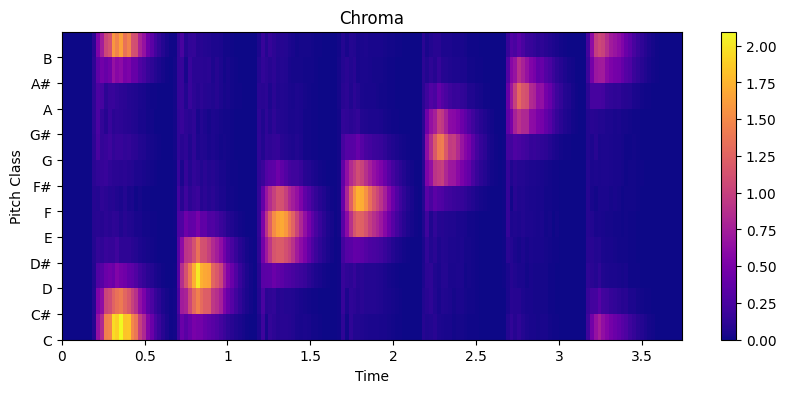

In [16]:
print(y_chroma_chunked.min(), y_chroma_chunked.max())

fig, ax = plt.subplots(figsize=(10, 4))
img = fill_spec(y_chroma_chunked, axes=ax, x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax.set_ylabel("Pitch Class")
ax.set_yticks(range(12))
ax.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
fig.colorbar(img, ax=ax)

Chromagram thresholded and then max normalized.

nan nan


/tmp/ipykernel_18767/2889146971.py:3: RuntimeWarning: invalid value encountered in divide
  y_chroma_chunked_thr = (y_chroma_chunked_thr / y_chroma_chunked_thr.max(0)).clip(0,1)


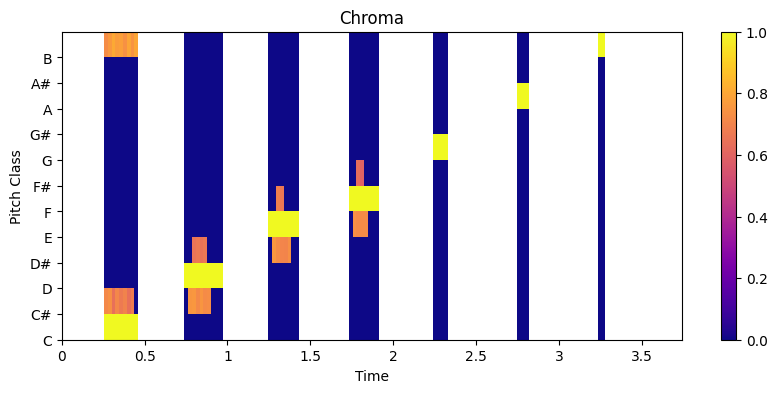

In [17]:
y_chroma_chunked_thr = y_chroma_chunked.copy()
y_chroma_chunked_thr[y_chroma_chunked_thr < 1] = 0
y_chroma_chunked_thr = (y_chroma_chunked_thr / y_chroma_chunked_thr.max(0)).clip(0, 1)

print(y_chroma_chunked_thr.min(), y_chroma_chunked_thr.max())

fig, ax = plt.subplots(figsize=(10, 4))
img = fill_spec(y_chroma_chunked_thr, axes=ax, x_coords=cqt_obj.x_coords(y.shape[-1]), x_axis="time", title="Chroma")
ax.set_ylabel("Pitch Class")
ax.set_yticks(range(12))
ax.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
fig.colorbar(img, ax=ax)

Does not work that well. Particularly the latter notes are truncated badly. And we still have some carryover effects to the neighbouring half notes.

In [23]:
np.zeros(0)

array([], dtype=float64)

In [25]:
librosa.frames_to_time(2, sr=42000, hop_length=hop_length)

np.float64(0.02438095238095238)